In [1]:
!pip install yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 12.2 MB/s  0:00:00 11.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [yfinance];237m━━━━ 8/9 [yfinance]s]


In [2]:
import yfinance as yf
import pandas as pd

# Apple'ın (AAPL) verilerini internetten canlı olarak çekiyoruz
df = yf.download("AAPL", start="2021-01-01", end="2026-07-01")

# İlk 5 satırını ekrana basıp kontrol ediyoruz
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-01-04,125.740829,129.821744,123.165964,129.734299,143301900
2021-01-05,127.295456,128.004769,124.788605,125.235569,97664900
2021-01-06,123.010513,127.334347,122.796750,124.098761,155088000
2021-01-07,127.208046,127.897922,124.234808,124.720632,109578200
2021-01-08,128.306046,128.869603,126.537640,128.675261,105158200


In [3]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1378.000000,1378.000000,1378.000000,1378.000000,1.378000e+03
mean,187.582422,189.467431,185.555416,187.421332,6.809678e+07
std,46.978765,47.389655,46.599252,46.971351,3.002873e+07
min,113.229790,117.161125,113.083823,115.827969,1.791060e+07
25%,147.673874,148.806784,145.614606,147.005572,4.691572e+07
50%,175.703918,177.415391,174.142561,175.448486,6.040765e+07
75%,224.179485,225.588866,221.536797,223.436879,8.218822e+07
max,315.200012,317.399994,309.649994,314.179993,3.186799e+08


In [4]:
df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [5]:
# Sadece kapanış fiyatı (Close) 180 dolardan büyük olan günleri filtreliyoruz
yuksek_gunler = df[df[('Close', 'AAPL')] > 180]

# Filtrelenmiş yeni tablonun ilk 5 satırına bakıyoruz
yuksek_gunler.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-06-12,181.249008,181.347632,178.468004,178.763859,54274900
2023-06-13,180.775681,181.604064,179.917713,180.272737,54929100
2023-06-14,181.406830,181.840749,179.503520,180.834847,57462900
2023-06-15,183.438324,183.941283,181.239159,181.416678,65433200
2023-06-16,182.363388,184.404777,181.722381,184.148362,101256200


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklerin arka planını daha şık ve okunaklı yapan modern bir tema seçelim
sns.set_theme(style="darkgrid")

Matplotlib is building the font cache; this may take a moment.


ModuleNotFoundError: No module named 'seaborn'

In [2]:
!pip install seaborn

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklerin arka planını daha şık ve okunaklı yapan modern bir tema seçelim
sns.set_theme(style="darkgrid")

In [7]:
import yfinance as yf
import pandas as pd

# Apple verilerini Yahoo Finance üzerinden tekrar çekiyoruz
df = yf.download("AAPL", start="2021-01-01", end="2026-07-01")
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-01-04,125.740829,129.821744,123.165964,129.734299,143301900
2021-01-05,127.295486,128.004800,124.788635,125.235599,97664900
2021-01-06,123.010506,127.334339,122.796742,124.098753,155088000
2021-01-07,127.208000,127.897876,124.234763,124.720587,109578200
2021-01-08,128.305984,128.869542,126.537580,128.675200,105158200


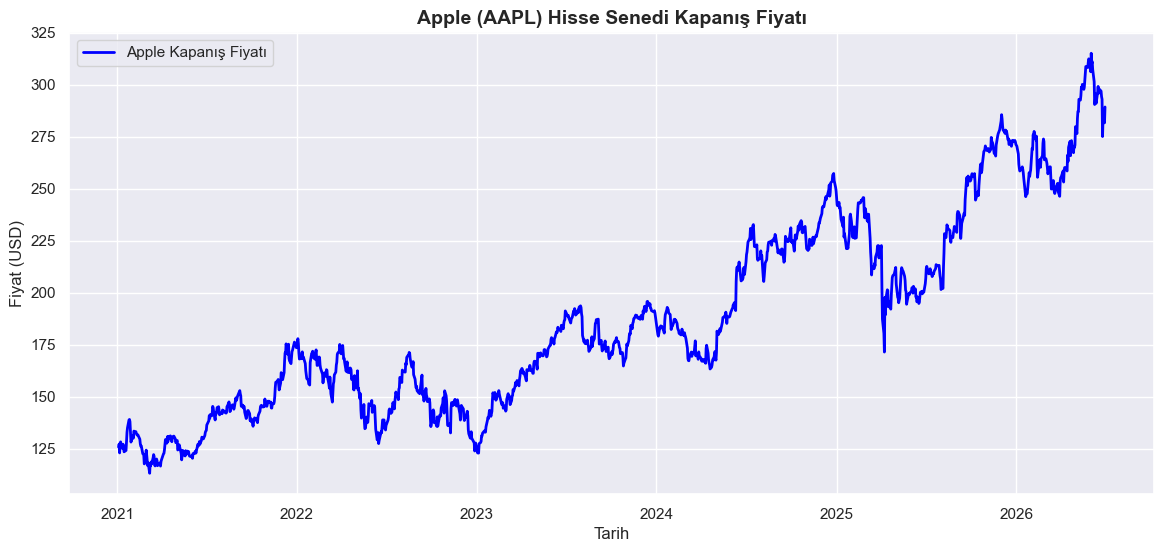

In [8]:
plt.figure(figsize=(14, 6))

# İki katmanlı sütun yapısına uygun şekilde ('Close', 'AAPL') olarak çağırıyoruz
plt.plot(df.index, df[('Close', 'AAPL')], color='blue', linewidth=2, label='Apple Kapanış Fiyatı')

plt.title('Apple (AAPL) Hisse Senedi Kapanış Fiyatı', fontsize=14, fontweight='bold')
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('Fiyat (USD)', fontsize=12)
plt.legend()
plt.show()

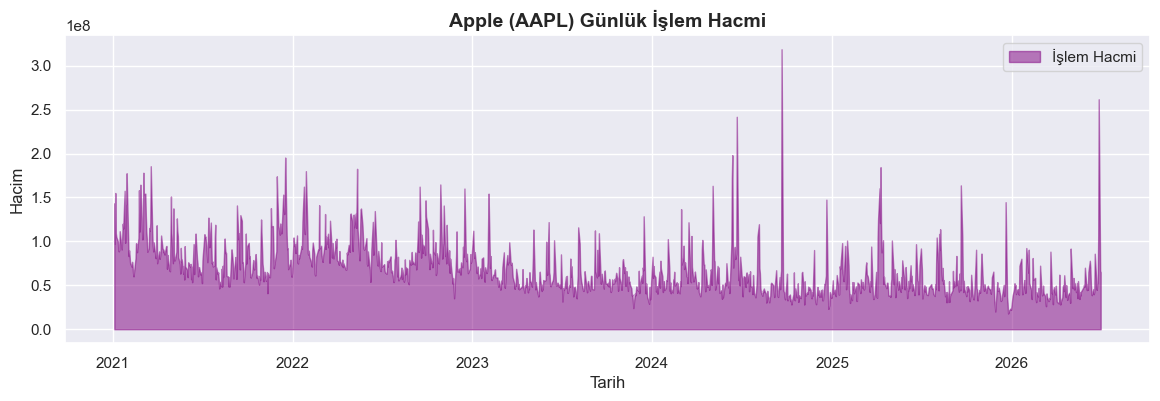

In [9]:
plt.figure(figsize=(14, 4))

# Hacim verisini iki katmanlı yapıya uygun çağırıp mor renkte çizdiriyoruz
plt.fill_between(df.index, df[('Volume', 'AAPL')], color='purple', alpha=0.5, label='İşlem Hacmi')

plt.title('Apple (AAPL) Günlük İşlem Hacmi', fontsize=14, fontweight='bold')
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('Hacim', fontsize=12)
plt.legend()
plt.show()

In [10]:
!pip install scikit-learn

In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Tarihleri (Index) sayısal bir formata çeviriyoruz ki model anlayabilsin
X = np.array(df.index.map(pd.Timestamp.to_julian_date)).reshape(-1, 1)

# 2. Tahmin etmek istediğimiz hedef değişken: Kapanış Fiyatı (Close)
y = df[('Close', 'AAPL')].values

# 3. Veriyi %80 Eğitim, %20 Test olarak bölüyoruz (Zaman sırasını bozmamak için shuffle=False yapıyoruz)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Eğitim veri seti boyutu: {X_train.shape[0]} gün")
print(f"Test veri seti boyutu: {X_test.shape[0]} gün")

Eğitim veri seti boyutu: 1102 gün
Test veri seti boyutu: 276 gün


In [12]:
# Modelimizi oluşturuyoruz
model = LinearRegression()

# Modeli eğitim verilerimizle eğitiyoruz (Öğrenme aşaması)
model.fit(X_train, y_train)

# Modelin test verilerine bakarak yaptığı tahminleri alıyoruz
y_pred = model.predict(X_test)

print("Model başarıyla eğitildi ve test verileri için tahminler yapıldı!")

Model başarıyla eğitildi ve test verileri için tahminler yapıldı!


--- Lineer Regresyon Sonuçları ---
Mean Squared Error (MSE): 943.28
Root Mean Squared Error (RMSE): 30.71
R2 Score: -0.04



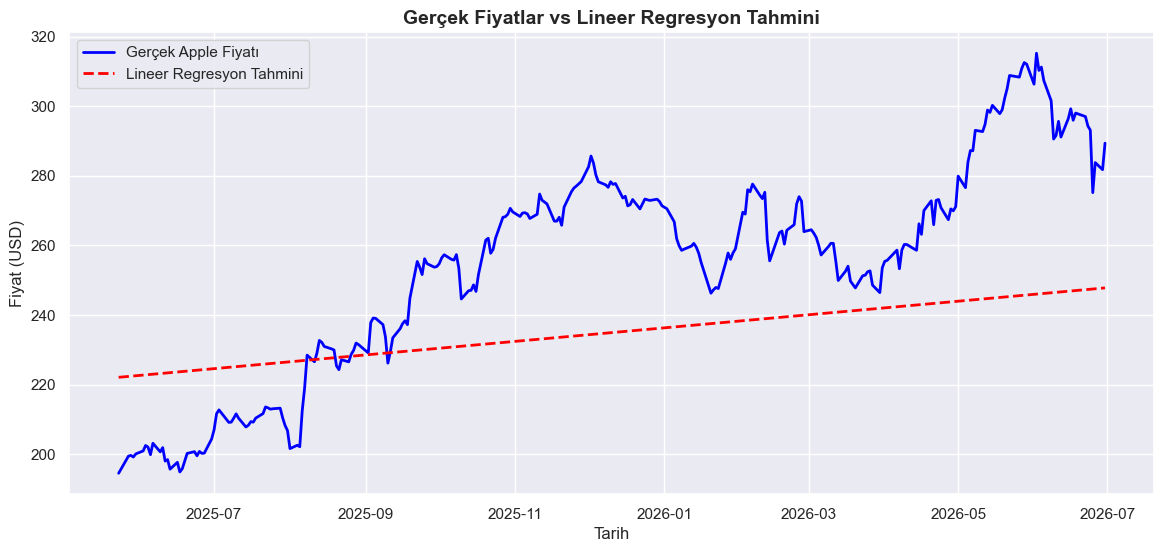

In [13]:
# 1. Metriklerin Hesaplanması (Hocanın istediği 4. Madde)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"--- Lineer Regresyon Sonuçları ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R2 Score: {r2:.2f}\n")

# 2. Gerçek vs Tahmin Grafiği (Hocanın istediği 5. Madde)
plt.figure(figsize=(14, 6))
# Gerçek fiyatlar (Mavi)
plt.plot(df.index[len(X_train):], y_test, color='blue', label='Gerçek Apple Fiyatı', linewidth=2)
# Modelin tahminleri (Kırmızı kesikli çizgi)
plt.plot(df.index[len(X_train):], y_pred, color='red', linestyle='--', label='Lineer Regresyon Tahmini', linewidth=2)

plt.title('Gerçek Fiyatlar vs Lineer Regresyon Tahmini', fontsize=14, fontweight='bold')
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('Fiyat (USD)', fontsize=12)
plt.legend()
plt.show()

### 📊 Model Analizi ve Yorumlar
* **Lineer Regresyon Analizi:** Yukarıdaki grafikte görüldüğü üzere, Lineer Regresyon modeli borsa gibi dalgalı ve karmaşık verilerde sadece genel "trendi" (yükseliş eğilimini) yakalayabilmiştir. Ancak günlük iniş çıkışları ve ani kırılmaları tahmin edememektedir. 
* **Sonraki Adım:** Bu yapısal eksikliği gidermek amacıyla, projenin sonraki aşamasında zaman serilerinde geçmiş verileri hafızasında tutarak çok daha başarılı sonuçlar veren **LSTM** ve **GRU** derin öğrenme modellerini kuracağız.

In [14]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.2/223.2 MB 7.8 MB/s  0:00:28 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 13.2 MB/s  0:00:003.4 MB/s eta 0:00:0101
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 9.7 MB/s  0:00:00m 12.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 1.9 MB/s  0:00:00m 15.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 18.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 14.1 MB/s  0:00:01 14.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [tensorflow]37m━━ 15/16 [tensorflow]


In [15]:
!pip install tensorflow

In [16]:
from sklearn.preprocessing import MinMaxScaler

# LSTM sadece Kapanış (Close) fiyatlarına bakarak öğrenecek
close_prices = df[('Close', 'AAPL')].values.reshape(-1, 1)

# Verileri 0 ile 1 arasına sıkıştırıyoruz (Yapay zekanın daha hızlı öğrenmesi için)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_prices)

print("Veriler başarıyla 0-1 arasına ölçeklendi!")

Veriler başarıyla 0-1 arasına ölçeklendi!


In [17]:
X_lstm, y_lstm = [], []

# Geçmiş 60 günü (Time Step) baz alarak yeni bir veri yapısı oluşturuyoruz
for i in range(60, len(scaled_data)):
    X_lstm.append(scaled_data[i-60:i, 0])
    y_lstm.append(scaled_data[i, 0])

X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)

# LSTM modelinin istediği 3 boyutlu (3D) formata getiriyoruz
X_lstm = np.reshape(X_lstm, (X_lstm.shape[0], X_lstm.shape[1], 1))

# Yine %80 Eğitim, %20 Test olarak bölüyoruz
train_size = int(len(X_lstm) * 0.8)
X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size:]
y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size:]

print(f"LSTM Eğitim Seti: {X_train_lstm.shape}")
print(f"LSTM Test Seti: {X_test_lstm.shape}")

LSTM Eğitim Seti: (1054, 60, 1)
LSTM Test Seti: (264, 60, 1)


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Katmanları üst üste ekleyeceğimiz boş bir model modeli oluşturuyoruz
lstm_model = Sequential()

# 1. LSTM Katmanı ve aşırı öğrenmeyi (overfitting) önlemek için Dropout
lstm_model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)))
lstm_model.add(Dropout(0.2))

# 2. LSTM Katmanı
lstm_model.add(LSTM(units=50, return_sequences=False))
lstm_model.add(Dropout(0.2))

# Çıkış Katmanı (Tek bir fiyat tahmin edeceği için 1)
lstm_model.add(Dense(units=1))

# Modeli derliyoruz
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# Modeli eğitiyoruz (Hızlı bitsin diye şimdilik 5 tur 'epochs' yapıyoruz)
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=5, batch_size=32)

print("\n🎉 LSTM Derin Öğrenme Modeli Başarıyla Eğtildi!")

Epoch 1/5


/opt/anaconda3/envs/ml_projesi/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0235
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0029
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0025
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0022
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0026

🎉 LSTM Derin Öğrenme Modeli Başarıyla Eğtildi!


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
--- LSTM Model Sonuçları ---
LSTM Mean Squared Error (MSE): 133.88
LSTM Root Mean Squared Error (RMSE): 11.57



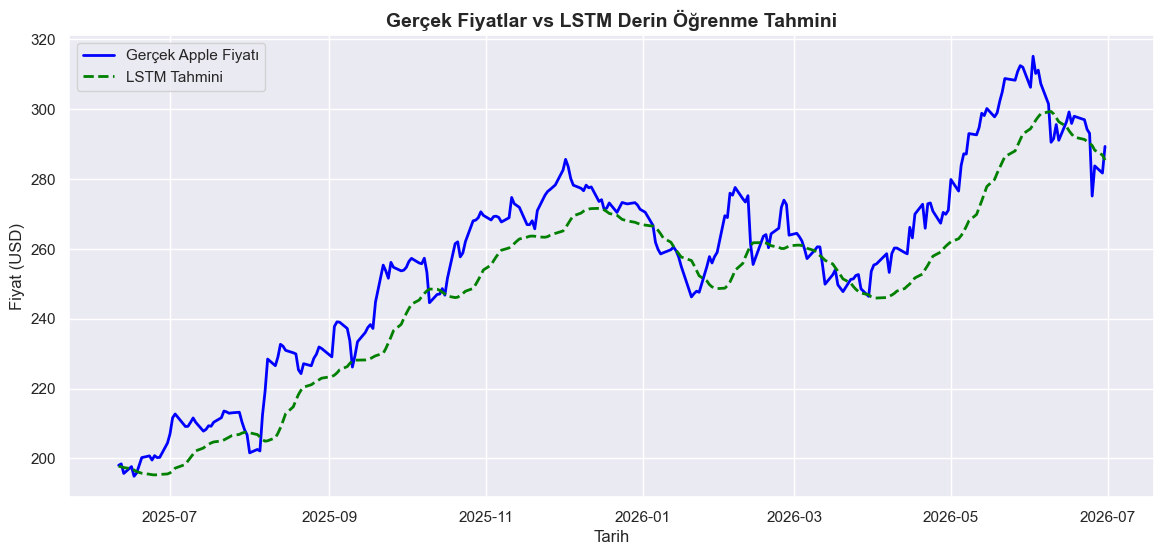

In [19]:
# 1. Test verilerini kullanarak modelin tahmin yapmasını sağlıyoruz
lstm_predictions = lstm_model.predict(X_test_lstm)

# 2. 0-1 arasındaki tahminleri gerçek USD fiyatlarına geri dönüştürüyoruz
lstm_predictions = scaler.inverse_transform(lstm_predictions)
y_test_real = scaler.inverse_transform(y_test_lstm.reshape(-1, 1))

# 3. LSTM Performans Metriklerinin Hesaplanması
lstm_mse = mean_squared_error(y_test_real, lstm_predictions)
lstm_rmse = np.sqrt(lstm_mse)

print(f"--- LSTM Model Sonuçları ---")
print(f"LSTM Mean Squared Error (MSE): {lstm_mse:.2f}")
print(f"LSTM Root Mean Squared Error (RMSE): {lstm_rmse:.2f}\n")

# 4. Gerçek vs LSTM Tahmin Grafiği
plt.figure(figsize=(14, 6))
plt.plot(df.index[train_size + 60:], y_test_real, color='blue', label='Gerçek Apple Fiyatı', linewidth=2)
plt.plot(df.index[train_size + 60:], lstm_predictions, color='green', linestyle='--', label='LSTM Tahmini', linewidth=2)

plt.title('Gerçek Fiyatlar vs LSTM Derin Öğrenme Tahmini', fontsize=14, fontweight='bold')
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('Fiyat (USD)', fontsize=12)
plt.legend()
plt.show()


In [20]:
from tensorflow.keras.layers import GRU

# 1. GRU Model Mimarisini Oluşturuyoruz
gru_model = Sequential()
gru_model.add(GRU(units=50, return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)))
gru_model.add(Dropout(0.2))
gru_model.add(GRU(units=50, return_sequences=False))
gru_model.add(Dropout(0.2))
gru_model.add(Dense(units=1))

# 2. Derleme ve Eğtme
gru_model.compile(optimizer='adam', loss='mean_squared_error')
gru_model.fit(X_train_lstm, y_train_lstm, epochs=5, batch_size=32)

# 3. Tahminleri Alma ve Geri Dönüştürme
gru_predictions = gru_model.predict(X_test_lstm)
gru_predictions = scaler.inverse_transform(gru_predictions)

# 4. GRU Metriklerinin Hesaplanması
gru_mse = mean_squared_error(y_test_real, gru_predictions)
gru_rmse = np.sqrt(gru_mse)

print(f"\n--- GRU Model Sonuçları ---")
print(f"GRU Mean Squared Error (MSE): {gru_mse:.2f}")
print(f"GRU Root Mean Squared Error (RMSE): {gru_rmse:.2f}")

Epoch 1/5


/opt/anaconda3/envs/ml_projesi/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0161
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0023
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0020
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0019
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0017
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step

--- GRU Model Sonuçları ---
GRU Mean Squared Error (MSE): 57.00
GRU Root Mean Squared Error (RMSE): 7.55


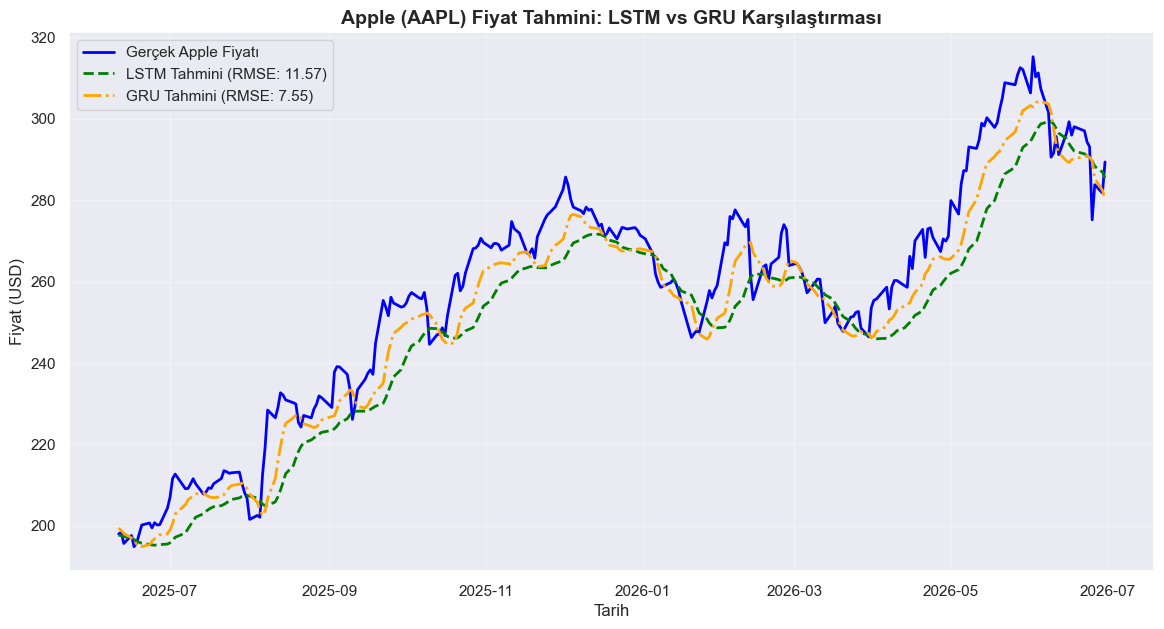

In [21]:
plt.figure(figsize=(14, 7))

# 1. Gerçek Fiyatlar (Mavi)
plt.plot(df.index[train_size + 60:], y_test_real, color='blue', label='Gerçek Apple Fiyatı', linewidth=2)

# 2. LSTM Tahminleri (Yeşil)
plt.plot(df.index[train_size + 60:], lstm_predictions, color='green', linestyle='--', label=f'LSTM Tahmini (RMSE: {lstm_rmse:.2f})', linewidth=2)

# 3. GRU Tahminleri (Turuncu)
plt.plot(df.index[train_size + 60:], gru_predictions, color='orange', linestyle='-.', label=f'GRU Tahmini (RMSE: {gru_rmse:.2f})', linewidth=2)

plt.title('Apple (AAPL) Fiyat Tahmini: LSTM vs GRU Karşılaştırması', fontsize=14, fontweight='bold')
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('Fiyat (USD)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

📊 LSTM ve GRU Model Karşılaştırma Analizi
Genel Değerlendirme: Hem LSTM hem de GRU modelleri, ilk başta denediğimiz düz Lineer Regresyon modeline kıyasla borsa verilerinde ezici bir üstünlük sağlamıştır. Düz bir trend çizgisi yerine, iki model de fiyatın tepe ve dip noktalarını (dalgalanmaları) çok yakından takip edebilmiştir.
Şampiyon GRU (RMSE: 7.55): Grafik net bir şekilde gösteriyor ki GRU modeli (turuncu çizgi), mavi renkli gerçek Apple fiyatına LSTM'den çok daha yakın seyretmektedir. Hata payı (RMSE) bazında GRU 7.55 puan ile LSTM'in (11.57) önüne geçerek bu veri setinde projenin en başarılı modeli olmuştur.
LSTM Performansı (RMSE: 11.57): LSTM (yeşil çizgi) genel yönü çok iyi tahmin etse de, fiyat değişimlerine GRU'ya göre biraz daha geriden (gecikmeli) tepki vermiş ve trendi hafifçe alttan takip etmiştir. GRU'nun daha az kapıya (gate) sahip olan sade mimarisi, bu veri setinde ani fiyat dalgalanmalarına daha hızlı adapte olmasını sağlamıştır.